# Learning Curves Sample

In this notebook, we will explore how to plot learning curves for a PyTorch neural network model. Learning curves are a useful tool for diagnosing the performance of a model and understanding how it learns over time.

For this example, we will use a simple feedforward neural network trained on the Flight Price Prediction dataset, which can be found on Kaggle [link](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction).

This is a regression problem, where the goal is to predict the price of a flight based on various features such as airline, departure time, arrival time, etc.

In [8]:
# Cambie de laptop entonces tengo que instalar cosas super basicas jaja 
!pip install kagglehub matplotlib pandas seaborn scikit-learn tqdm

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.1 MB 11.0 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 12.5 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 13.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 13.4 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 3.7/37.3 MB 19.1 MB/s eta 0:00:02
   ------- -------------------------------- 6.8/37.3 MB 17.6 MB/s eta 0:00:02
   ------------ --------------------------- 11.3/37.3 MB 18.7 MB/s eta 0:00:02
   ---------------- ----------------------- 15.7/37.3 MB 19.5 MB/s eta 0:00:02
   --------------------- ------------------ 20.2/37.3 MB 19.8 MB/s eta 0:00:01
   -------------------------- ------------- 24.9/37.3 MB 20.4 MB/s eta 0:00:01
   ------------------------------- -------- 29.6/37.3 MB 20.9 MB/s eta 0:00:01
   --

In [4]:
# Este es para el pytorch con cuda compatible con mi driver de nvidia cuda
pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
# Para checar si jalo el pytorch con cuda
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.10.0+cu128
True
NVIDIA GeForce RTX 4090 Laptop GPU


In [2]:
import math
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Esta celda ya estaba y es para ver tambien si funciona la GPU para el pytorch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## EDA

Let's start by loading and understanding the dataset. For simplicity, the data will be loaded into a Pandas DataFrame during this and the preprocessing phase. Once we are ready to start training the model, it will be converted into PyTorch tensors.


In [4]:
path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")

print("Path to dataset files:", path)

100%|██████████| 4.16M/4.16M [00:00<00:00, 7.93MB/s]

Extracting files...
Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\shubhambathwal\flight-price-prediction\versions\2


The dataset contains various files. We are only concerned with the `Clean_Dataset.csv` file for our analysis.

In [5]:
data = pd.read_csv(f"{path}/Clean_Dataset.csv")

data

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


<Axes: xlabel='price', ylabel='Count'>

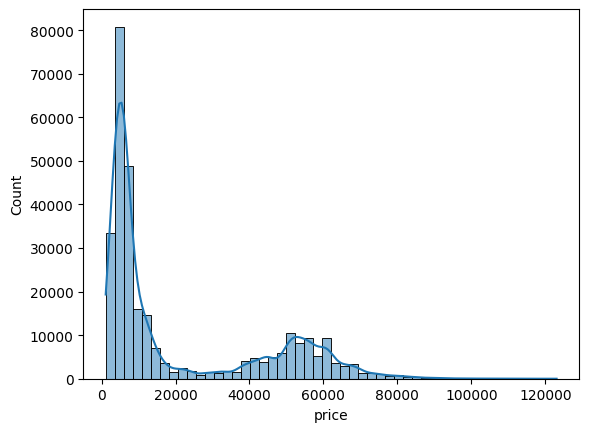

In [6]:
sns.histplot(data["price"], bins=50, kde=True)

**Outliers ligeros^^**

In [7]:
numerical_cols = ["duration", "days_left"]

data[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,300153.0,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,26.004751,13.561004,1.00,15.00,26.00,38.00,49.00


In [8]:
categorical_cols = ["airline", "flight", "source_city", "destination_city", "class", "departure_time", "arrival_time",
                    "stops"]

data[categorical_cols].describe().T

,count,unique,top,freq
airline,300153,6,Vistara,127859
flight,300153,1561,UK-706,3235
source_city,300153,6,Delhi,61343
destination_city,300153,6,Mumbai,59097
class,300153,2,Economy,206666
departure_time,300153,6,Morning,71146
arrival_time,300153,6,Night,91538
stops,300153,3,one,250863


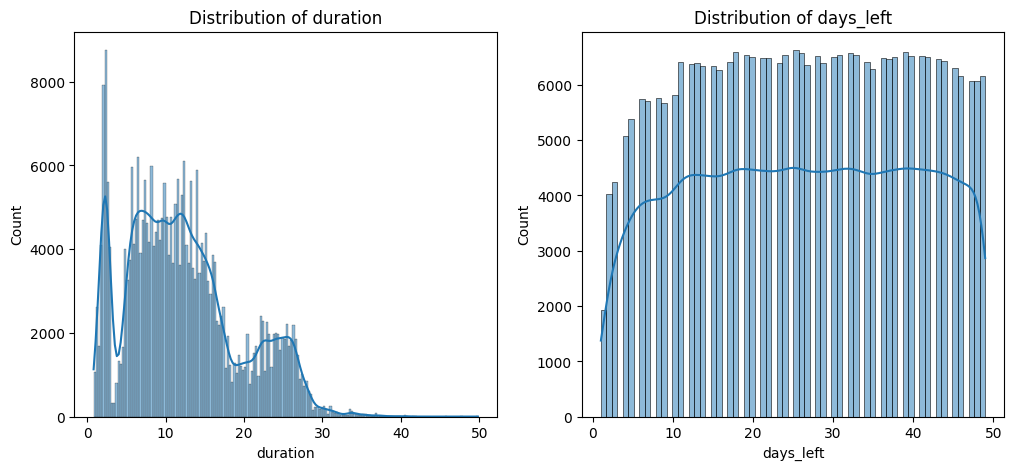

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

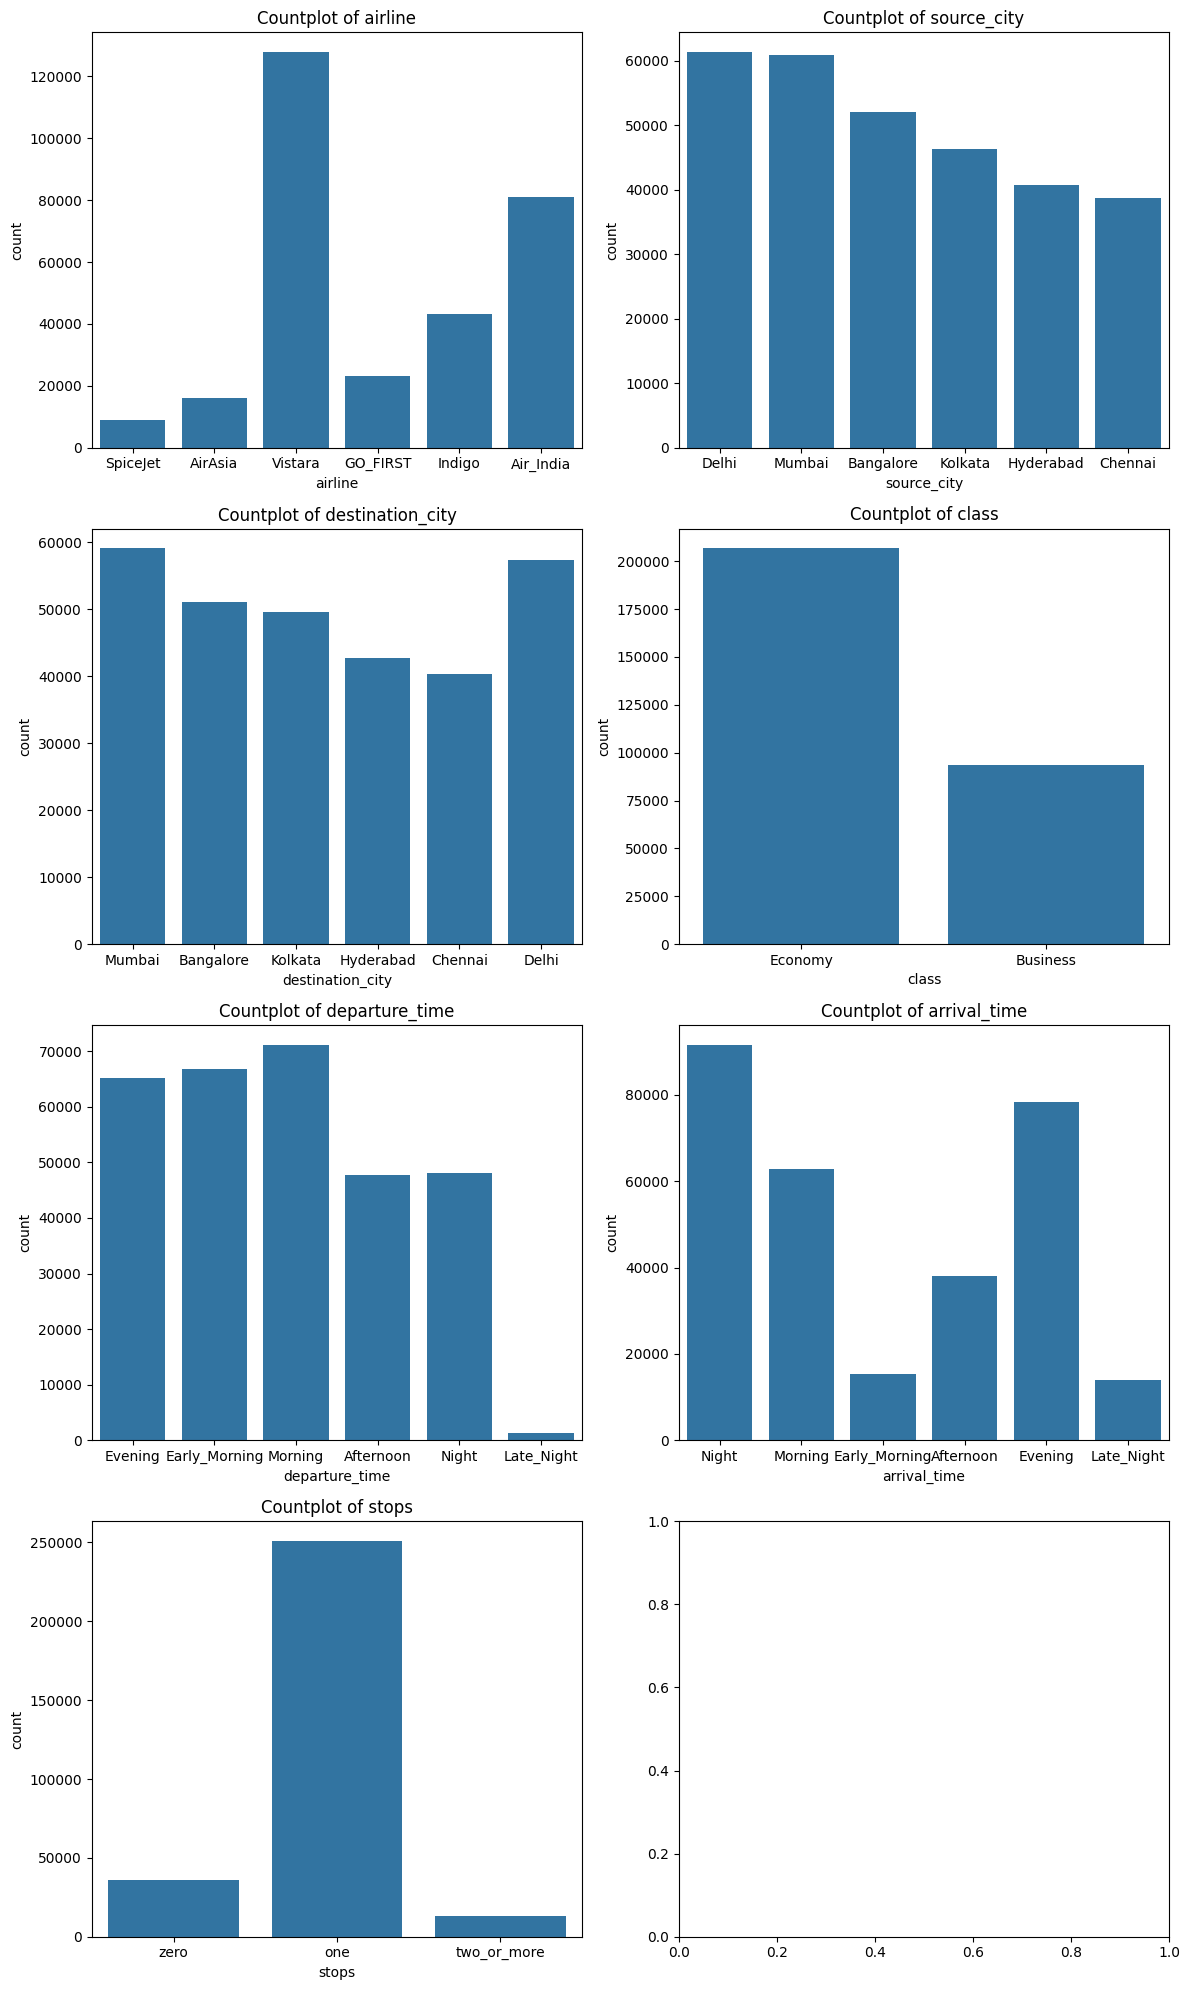

In [10]:
fig, axs = plt.subplots(4, 2, figsize=(12, 20))
cols = [c for c in categorical_cols if c != "flight"]

for ax, col in zip(axs.ravel(), cols):
    sns.countplot(data=data, x=col, ax=ax)
    ax.set_title(f'Countplot of {col}')

plt.tight_layout()


## Preprocessing

For this dataset, we will perform the following preprocessing steps:
- One-hot encode categorical features (airline, source_city, destination_city).
- Apply standard scaling to numerical features (duration, days_left).
- Ordinal-encode ordinal features (departure_time, arrival_time, stops, class).
- Drop flight column; it has very high cardinality, and it is related to airline, source_city and destination_city features.
- For the target column, divide it by 100 to make the values more manageable for the model and for end user interpretability. Since the prices are expressed in Indian Rupees, this will roughly convert the prices to USD, which is more familiar to a wider audience.

In [11]:
x_train, x_test, y_train, y_testval = train_test_split(
    data.drop(columns=["price", "flight"]),
    data["price"],
    test_size=0.3,
    random_state=42,
)

x_test, x_val, y_test, y_val = train_test_split(
    x_test,
    y_testval,
    test_size=0.5,
    random_state=42,
)

To ensure consistent encoding, we first create a list of known categories for each categorical feature. We will use this to:
- Ensure that columns that share a common set of categories (e.g., departure_time and arrival_time) are encoded consistently.
- Enforce an order for ordinal features.

In [12]:
airline_categories = list(data['airline'].unique())
city_categories = list(set(data['source_city'].unique()).union(set(data['destination_city'].unique())))

stops_categories = ["zero", "one", "two_or_more"]
class_categories = ["Economy", "Business"]
flight_time_categories = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]


In [13]:
preprocessing = make_pipeline(
    ColumnTransformer(
        transformers=[
            (
                "onehot",
                OneHotEncoder(categories=[airline_categories, city_categories, city_categories], drop="first"),
                ["airline", "source_city", "destination_city"],
            ),
            (
                "ordinal",
                OrdinalEncoder(
                    categories=[
                        flight_time_categories,
                        flight_time_categories,
                        stops_categories,
                        class_categories
                    ]
                ),
                ["departure_time", "arrival_time", "stops", "class"],
            ),
            (
                "scaler",
                StandardScaler(),
                ["duration", "days_left"],
            ),
        ]
    ))



In [14]:
x_train_preprocessed = preprocessing.fit_transform(x_train)
x_val_preprocessed = preprocessing.transform(x_val)
x_test_preprocessed = preprocessing.transform(x_test)

y_train_preprocessed = y_train / 100
y_val_preprocessed = y_val / 100
y_test_preprocessed = y_test / 100

Now, create our custom PyTorch dataset for training, validation, and testing.

In [15]:
class FlightPriceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1).to(device)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [16]:
train_data = FlightPriceDataset(x_train_preprocessed, y_train_preprocessed)
val_data = FlightPriceDataset(x_val_preprocessed, y_val_preprocessed)
test_data = FlightPriceDataset(x_test_preprocessed, y_test_preprocessed)

## Training Loop with Learning Curves

Let's start by creating our train function. It will handle training and will evaluate loss on the validation set at the end of each epoch.

In [ ]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    """
    Train the model and record training and validation losses for each epoch.
    Note that the input model will be mutated.
    For each epoch, loss is averaged across
    :return: Two lists: training_losses and validation_losses.
    """
    # Definimos las listas que vamos a returnear, no importa que este afuera del for loop porque esta adentro de la funcion y siempre se inicializan en 0 
    # Antes de iniciar el entrenamiento y terminar todos los epochs entonces perfecto 
    train_losses = []
    val_losses = []
    for epoch in range(_num_epochs):
        _model.train()
        running_loss = 0.0
        for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch + 1}/{_num_epochs}"):
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            running_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)

        epoch_val_loss = val_loss / len(_val_loader.dataset)

# Hacemos append del train loss y val loss del epoch a nuestra lista que vamos a returnear
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        print(f"epoch {epoch+1} loss: {epoch_train_loss:.2f} (train) | {epoch_val_loss:.2f} (val)")

    return train_losses, val_losses # Okay agregue el return de las 2 listas con los train lossess y val lossess porque las necesito y no venian en el codigo original
# Me estaba dando mucho error jajaja ploteando las loss curves pero era que esta funcion no regresaba nada sino nomas el print, pero ya lo modifique y funciona el plot

For this exercise, we will intentionally cause overfitting by using a small subset of the training data, a relatively complex model, and training for more epochs than needed. This will allow us to see the characteristic learning curves of an overfitting model, where the training loss decreases while the validation loss starts to increase after a certain point.

In [64]:
train_subset = torch.utils.data.Subset(train_data, indices=range(500))

model = nn.Sequential(
    nn.Linear(train_data.X.shape[1], 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 100
batch_size = 64

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)

train_losses, val_losses = train(model, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/100: 100%|██████████| 8/8 [00:00<00:00, 243.57it/s]


epoch 1 loss: 98555.82 (train) | 92734.05 (val)


Epoch 2/100: 100%|██████████| 8/8 [00:00<00:00, 454.59it/s]


epoch 2 loss: 95596.44 (train) | 87153.93 (val)


Epoch 3/100: 100%|██████████| 8/8 [00:00<00:00, 584.76it/s]


...

epoch 98 loss: 1039.96 (train) | 3314.10 (val)


Epoch 99/100: 100%|██████████| 8/8 [00:00<00:00, 655.28it/s]


epoch 99 loss: 1036.11 (train) | 3336.00 (val)


Epoch 100/100: 100%|██████████| 8/8 [00:00<00:00, 676.46it/s]


epoch 100 loss: 1051.26 (train) | 3396.52 (val)


**Okay antes de pasar a las curvas, solamente viendo lo de la consola si hay overfitting porque el loss del train sigue bajando hasta menos de 1000 jajajaj y el loss de val si se quedo fijo arriba de 3300, overfitting**

Tambien pues modifique a 100 epochs, por eso se desarrollo mas el overfitting:
- epoch 100 loss: 808.86 (train) | 3458.51 (val)


Let's now define the function to plot the learning curves for training and validation loss.

In [65]:
import matplotlib.pyplot as plt

def plot_learning_curves(_train_losses, _val_losses):
    #Ok yo estaba pasando num_epochs crudo y eso me dio error varias veces, tengo que construir la lista con range como el ejemplo de la diapositiva
    epochs = range(1, num_epochs+1 )

    plt.plot(epochs,_train_losses, label="Curva de perdida del entrenamiento")
    plt.plot(epochs,_val_losses, label="Curva de perdida en validacion")
    plt.xlabel("Epoch")
    plt.ylabel("Perdida")
    plt.title("Curvas de perdida")
    plt.legend()
    plt.show()


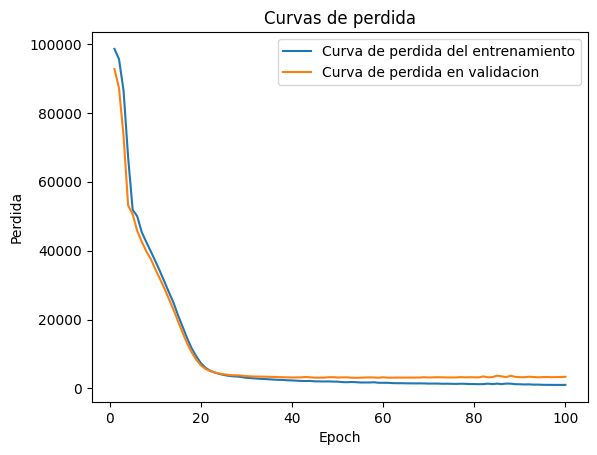

In [66]:
plot_learning_curves(train_losses, val_losses)

### **Okay podemos ver que a partir del epoch 40 mas o menos se empieza a desprender la curva de perdida de entrenamiento de la validacion lo que significa que SI hay overfitting**

### Lo que voy a hacer primero es implementar dropout en la arquitectura de la red neuronal junto con L2 Regularization antes de implementar early stopping para ver si podemos hacer que deje de hacer overfitting aunque se entrenen muchas epochs sin necesidad de early stopping (mala practica, pero vale la pena probar jaja)

In [67]:
# VUELVO A DEFINIR LA ARQUITECTURA, REUTILIZO CODIGO 
train_subset = torch.utils.data.Subset(train_data, indices=range(500))

model = nn.Sequential(
    nn.Linear(train_data.X.shape[1], 512), # CAPA DE INPUT PASA A CAPA OCULTA DE 512
    nn.ReLU(),
    nn.Dropout(p=0.5), # APLICAMOS DROPUT del 50%, super alto el valor pero es la capa densa mas grande (512), entonces como primer experimento va esta
    nn.Linear(512, 256),  # CAPA OCULTA DE 512 PASA A CAPA OCULTA DE 256
    nn.ReLU(),
    nn.Dropout(p=0.3), # APLICAMOS DROPUT del 30%, sigue siendo una capa relativamente grande por eso 30$
    nn.Linear(256, 128),  # CAPA OCULTA DE 256 PASA A CAPA OCULTA DE 128 
    nn.ReLU(),
    nn.Dropout(p=0.2), # APLICAMOS DROPUT del 20%, ya que quiero mantener los valores altos jaja
    nn.Linear(128, 1)     # CAPA OCULTA DE 128 PASA A CAPAD DE OUTPUT ( 1 NEURONA PORQUE ES REGRESION)
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # Okay aqui en el optimizador ADAM agregare el L2 Regularization que es el parametro de weight decay
# Este valor de weight decay lo dejo en un baseline super general que he visto que se usa mucho incluso en la presentacion del profe
num_epochs = 100
batch_size = 64

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)

train_losses, val_losses = train(model, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/100: 100%|██████████| 8/8 [00:00<00:00, 211.55it/s]


epoch 1 loss: 98460.58 (train) | 92462.78 (val)


Epoch 2/100: 100%|██████████| 8/8 [00:00<00:00, 463.44it/s]


epoch 2 loss: 94733.90 (train) | 85038.94 (val)


Epoch 3/100: 100%|██████████| 8/8 [00:00<00:00, 507.49it/s]


...

epoch 98 loss: 3197.43 (train) | 3064.97 (val)


Epoch 99/100: 100%|██████████| 8/8 [00:00<00:00, 589.63it/s]


epoch 99 loss: 2913.71 (train) | 3129.88 (val)


Epoch 100/100: 100%|██████████| 8/8 [00:00<00:00, 608.32it/s]


epoch 100 loss: 2778.82 (train) | 3078.88 (val)


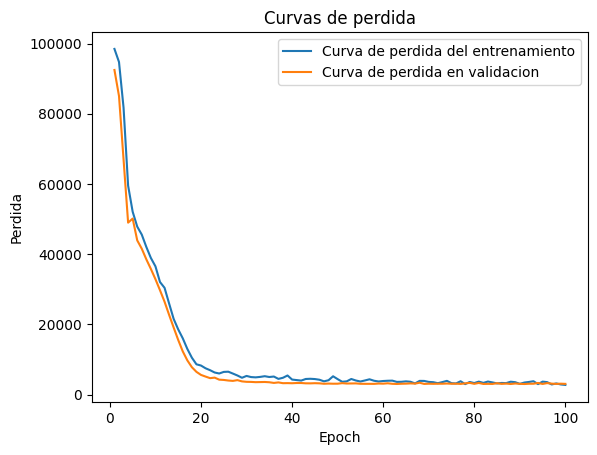

In [68]:
plot_learning_curves(train_losses, val_losses)

**OKAY SUPER BIEN, y a la primera, literalmente no pense que fuera hasta a mejorar el rendimiento del modelo :0**

Osea no solo previnimos el overfitting, si no que literalmente mejoro el rendimiento del modelo considerablemente y solo con L2 regularization y un Droupout considerablemente alto, no pense que fuera a pasar esto jajaj pero esta super bien porque si hubiera optado por implementar el early stoppage o guardar el mejor modelo entonces no hubiera mejorado el rendimiento de la red neuronal, solamente hubiera guardado el mejor epoch pero con el entrenamiento pasado basicamente, no mejorado

## Final Evaluation

Finally, we will evaluate the model on the test set to see how it performs on unseen data.

In [20]:
test_loader = DataLoader(test_data, batch_size=batch_size)

test_loss_batch = 0.0
with torch.no_grad():
    for X_val, y_test in test_loader:
        test_outputs = model(X_val)
        test_loss_batch += criterion(test_outputs, y_test).item() * X_val.size(0)

test_loss = test_loss_batch / len(test_loader.dataset)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(
    f"A prediction made by this model will be off by roughly {math.sqrt(test_loss) * 100:.2f} Rupees (about {math.sqrt(test_loss):.2f} USD) from the actual price on average.")

Test Loss (MSE): 3284.3614
A prediction made by this model will be off by roughly 5730.93 Rupees (about 57.31 USD) from the actual price on average.


**Okay de una se lo voy a pasar a el final evaluation para ver si mejoro el rendimiento**

In [69]:
test_loader = DataLoader(test_data, batch_size=batch_size)

test_loss_batch = 0.0
with torch.no_grad():
    for X_val, y_test in test_loader:
        test_outputs = model(X_val)
        test_loss_batch += criterion(test_outputs, y_test).item() * X_val.size(0)

test_loss = test_loss_batch / len(test_loader.dataset)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(
    f"A prediction made by this model will be off by roughly {math.sqrt(test_loss) * 100:.2f} Rupees (about {math.sqrt(test_loss):.2f} USD) from the actual price on average.")

Test Loss (MSE): 3197.2345
A prediction made by this model will be off by roughly 5654.41 Rupees (about 56.54 USD) from the actual price on average.
